# Notebook Prerequisites

- **Kernel / Python:** Use the project's virtual environment (see `pyproject.toml`).
- **Required packages:** Install project deps (e.g., `xgboost`, `pandas`, `scikit-learn`).
- **Data:** Processed datasets live at `data/processed`. Run `02_feature_eng_encoding.ipynb` first if files are missing.
- **MLflow / Artifacts:** MLflow uses `mlruns/` at the repo root for local runs.

✅ Notes for this setup

- No feature scaling → XGBoost doesn’t need it.

- No need to drop multicollinear features → trees handle it naturally.

- Default hyperparameters already give strong performance.

Later you can:

- Tune max_depth, learning_rate, n_estimators.

- Use early_stopping_rounds with a validation set.

- Check feature importance with xgb.feature_importances_.

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ================================================
# 2. Load datasets (feature engineered, leakage-safe)
# ================================================
DATA_DIR = Path("../data/processed")
train_path = DATA_DIR / "feature_engineered_train.csv"
eval_path = DATA_DIR / "feature_engineered_eval.csv"

if not train_path.exists() or not eval_path.exists():
    raise FileNotFoundError(
        f"Expected processed files at {DATA_DIR.resolve()} - run `02_feature_eng_encoding.ipynb` first to create them."
    )

train_df = pd.read_csv(train_path)
eval_df = pd.read_csv(eval_path)

# ================================================
# 3. Define target & features
# ================================================
target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_eval = eval_df.drop(columns=[target])
y_eval = eval_df[target]

# Align eval to train features if there is a mismatch (helps demo + small test runs)
missing_cols = [c for c in X_train.columns if c not in X_eval.columns]
if missing_cols:
    print(f"⚠️ Eval set is missing {len(missing_cols)} columns compared to train. Filling missing columns with 0 for demo purposes.")
    for c in missing_cols:
        X_eval[c] = 0

# Re-order columns to match
X_eval = X_eval.reindex(columns=X_train.columns)

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

# ================================================
# 4. Train a simple XGBoost Regressor
# ================================================
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ================================================
# 5. Evaluate performance
# ================================================
y_pred = xgb_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("XGBoost Performance:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

Train shape: (576815, 37)
Eval shape: (148448, 37)
XGBoost Performance:
MAE: 32,309.80
RMSE: 71,422.37
R²: 0.9606


In [5]:
X_train.columns

Index(['year', 'quarter', 'month', 'median_list_price', 'median_ppsf',
       'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'off_market_in_two_weeks', 'bank', 'bus', 'hospital', 'mall', 'park',
       'restaurant', 'school', 'station', 'supermarket', 'Total Population',
       'Median Age', 'Per Capita Income', 'Total Families Below Poverty',
       'Total Housing Units', 'Median Rent', 'Median Home Value',
       'Total Labor Force', 'Unemployed Population',
       'Total School Age Population', 'Total School Enrollment',
       'Median Commute Time', 'zipcode_freq', 'city_encoded'],
      dtype='object')

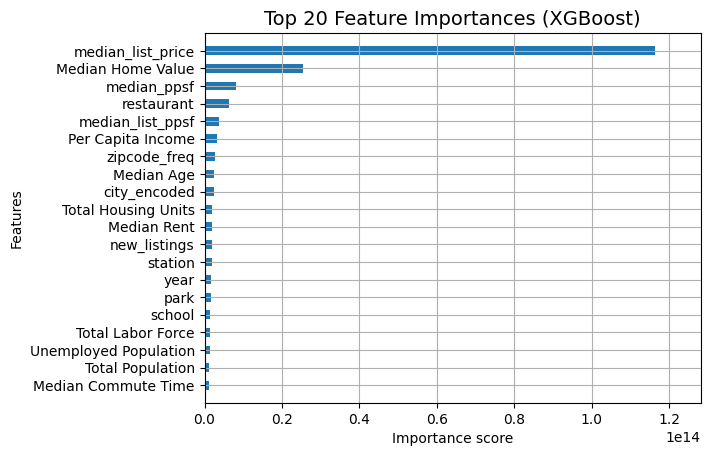

In [6]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()